<a href="https://colab.research.google.com/github/yovictoraugusto/Bioinformatica-Avancada_Analise-Dados-Cancer-Colorretal/blob/main/Trabalho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução

# Objetivo

# Dados utilizados

# Instalação e importação das bibliotecas

In [1]:
!pip install GEOparse biopython pandas numpy scipy statsmodels seaborn matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 13.1 MB/s eta 0:00:00


In [2]:
import GEOparse
import pandas as pd
import numpy as np

from scipy import stats
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from Bio import Entrez

# Download dos dados

In [3]:
# site: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE41258

gse = GEOparse.get_GEO("GSE41258", destdir="./data")

29-Jun-2026 16:43:54 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE41nnn/GSE41258/soft/GSE41258_family.soft.gz to ./data/GSE41258_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE41nnn/GSE41258/soft/GSE41258_family.soft.gz to ./data/GSE41258_family.soft.gz
100%|██████████| 46.2M/46.2M [00:04<00:00, 10.9MB/s]
29-Jun-2026 16:44:00 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
29-Jun-2026 16:44:00 DEBUG downloader - Moving /tmp/tmpqg15zki_ to /content/data/GSE41258_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpqg15zki_ to /content/data/GSE41258_family.soft.gz
29-Jun-2026 16:44:00 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE41nnn/GSE41258/soft/GSE41258_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE41nnn/GSE41258/soft/GSE41258_family.soft.gz
29-Jun-2026 16:44:00 INFO GEOparse - Parsing ./data/GSE41258_family.soft.gz

# Explorar os metadados

In [4]:
# IDs das primeiras amostras
list(gse.gsms.keys())[:5]

['GSM1012278', 'GSM1012279', 'GSM1012280', 'GSM1012281', 'GSM1012282']

In [5]:
# Mostrandos todos os dados da primeira amostra
gsm_id = list(gse.gsms.keys())[0]
gse.gsms[gsm_id].metadata

{'title': ['Polyp 00300BR2'],
 'geo_accession': ['GSM1012278'],
 'status': ['Public on Oct 02 2012'],
 'submission_date': ['Oct 01 2012'],
 'last_update_date': ['Oct 09 2012'],
 'type': ['RNA'],
 'channel_count': ['1'],
 'source_name_ch1': ['Tissue samples taken from colorectal cancer patients'],
 'organism_ch1': ['Homo sapiens'],
 'taxid_ch1': ['9606'],
 'characteristics_ch1': ['tissue: Polyp',
  'scan date: 25/02/2004',
  'patient id: 300',
  'included in analysis: Yes'],
 'molecule_ch1': ['total RNA'],
 'extract_protocol_ch1': ['standard Affymetrix protocol'],
 'label_ch1': ['biotin'],
 'label_protocol_ch1': ['standard Affymetrix protocol'],
 'hyb_protocol': ['standard Affymetrix protocol'],
 'scan_protocol': ['standard Affymetrix protocol'],
 'description': ['Polyp 00300BR2 00300BR2'],
 'data_processing': ['data was summarized using PLIER algorithm'],
 'platform_id': ['GPL96'],
 'contact_name': ['Michal,,Sheffer'],
 'contact_institute': ['Weizmann Institute of Science'],
 'contact_

In [6]:
# listando as 5 primeiras linhas com as colunas pré-selecionadas
metadata = []

for gsm_name, gsm in gse.gsms.items():
    row = {
        "sample_id": gsm_name,
        "title": gsm.metadata.get("title", [""])[0],
        "source_name": gsm.metadata.get("source_name_ch1", [""])[0],
        "characteristics": "; ".join(gsm.metadata.get("characteristics_ch1", []))
    }
    metadata.append(row)

metadata_df = pd.DataFrame(metadata)
metadata_df.head()

,sample_id,title,source_name,characteristics
0,GSM1012278,Polyp 00300BR2,Tissue samples taken from colorectal cancer pa...,tissue: Polyp; scan date: 25/02/2004; patient ...
1,GSM1012279,Liver Metastasis 00450UR1,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 13/02/200...
2,GSM1012280,Liver Metastasis 00450UR1_ez,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 13/02/200...
3,GSM1012281,Liver Metastasis 00450UR2,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 13/02/200...
4,GSM1012282,Liver Metastasis 00464UR1,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 37659; pa...


In [7]:
metadata_df[["sample_id", "title", "source_name", "characteristics"]].head(20)

,sample_id,title,source_name,characteristics
0,GSM1012278,Polyp 00300BR2,Tissue samples taken from colorectal cancer pa...,tissue: Polyp; scan date: 25/02/2004; patient ...
1,GSM1012279,Liver Metastasis 00450UR1,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 13/02/200...
2,GSM1012280,Liver Metastasis 00450UR1_ez,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 13/02/200...
3,GSM1012281,Liver Metastasis 00450UR2,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 13/02/200...
4,GSM1012282,Liver Metastasis 00464UR1,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 37659; pa...
5,GSM1012283,Liver Metastasis 00485UR1,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 37659; pa...
6,GSM1012284,Liver Metastasis 00485UR1_ez,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 37664; pa...
7,GSM1012285,Liver Metastasis 00485UR2,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 13/02/200...
8,GSM1012286,Primary Tumor 00620AR1,Tissue samples taken from colorectal cancer pa...,tissue: Primary Tumor; scan date: 37687; patie...
9,GSM1012287,Liver Metastasis 00823UR1,Tissue samples taken from colorectal cancer pa...,tissue: Liver Metastasis; scan date: 37659; pa...


# Organização das amostras

In [8]:
def classify_sample(row):
    text = " ".join([
        str(row["title"]),
        str(row["source_name"]),
        str(row["characteristics"])
    ]).lower()

    if "normal" in text or "mucosa" in text:
        return "Normal"
    elif "carcinoma" in text or "adenocarcinoma" in text or "tumor" in text:
        return "Tumor"
    else:
        return "Other"

metadata_df["group"] = metadata_df.apply(classify_sample, axis = 1)
metadata_df["group"].value_counts()

,count
group,
Tumor,186
Other,130
Normal,74


In [9]:
metadata_filtered = metadata_df[metadata_df["group"].isin(["Tumor", "Normal"])].copy()
metadata_filtered["group"].value_counts()

,count
group,
Tumor,186
Normal,74


# Matriz de expressão gênica



*   Linha: genes/probes;
*   Colunas: amostras/pacientes;
*   Valores: Nível de expressão gênica.



In [10]:
expression_data = []

for gsm_name, gsm in gse.gsms.items():
    if gsm_name in metadata_filtered["sample_id"].values:
        table = gsm.table

        sample_expression = table[["ID_REF", "VALUE"]].copy()
        sample_expression.columns = ["probe_id", gsm_name]
        expression_data.append(sample_expression.set_index("probe_id"))

expr_df = pd.concat(expression_data, axis = 1)
expr_df.head()

,GSM1012286,GSM1012294,GSM1012297,GSM1012298,GSM1012301,GSM1012303,GSM1012304,GSM1012305,GSM1012306,GSM1012307,...,GSM1012644,GSM1012645,GSM1012646,GSM1012647,GSM1012648,GSM1012649,GSM1012651,GSM1012652,GSM1012653,GSM1012654
probe_id,,,,,,,,,,,,,,,,,,,,,
1007_s_at,463.0,29.1,583.0,246.0,256.0,440.0,416.0,228.0,408.0,594.0,...,42.7,447.0,317.0,67.6,482.0,71.9,435.0,356.0,336.0,42.0
1053_at,23.2,35.2,28.1,33.6,35.4,52.0,44.4,38.1,37.0,61.7,...,46.5,78.2,42.4,38.1,26.0,34.1,22.8,27.7,42.1,14.0
117_at,40.1,71.6,53.1,74.5,60.2,50.3,56.2,40.8,48.2,70.8,...,63.3,69.9,52.2,69.5,45.8,55.7,77.8,57.3,45.0,78.1
121_at,270.0,198.0,235.0,206.0,187.0,197.0,181.0,200.0,217.0,182.0,...,206.0,248.0,201.0,185.0,222.0,194.0,481.0,273.0,145.0,320.0
1255_g_at,45.0,38.6,38.4,32.9,33.0,24.0,35.7,22.7,28.3,34.1,...,24.0,31.3,32.6,32.3,34.0,31.6,69.6,31.4,24.3,34.3


# Limpeza dos dados

Os dados do GSE41258 foram obtidos já normalizados pelo método PLIER (Probe Logarithmic Intensity Error), conforme descrito pelos autores do estudo original.

In [11]:
# transforma os dados em números
expr_df = expr_df.apply(pd.to_numeric, errors = "coerce")

# Dropa linhas com muitas células vazias
expr_df = expr_df.dropna(thresh = int(expr_df.shape[1] * 0.8))

# Nas células vazias, adiciona a mediana da linha
expr_df = expr_df.T.fillna(expr_df.median(axis=1)).T

expr_df.shape

(22283, 260)

# Análise exploratória

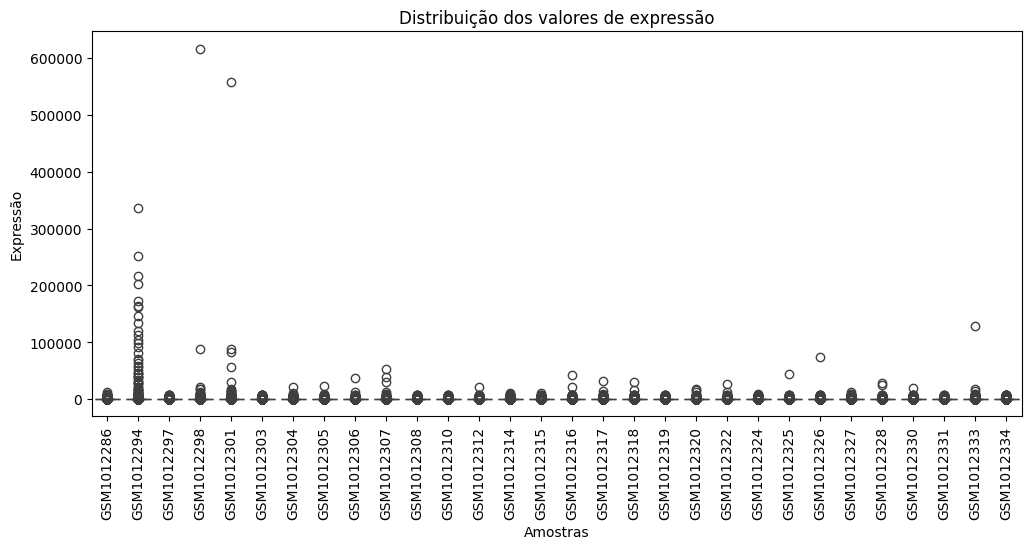

In [12]:
plt.figure(figsize = (12,5))
sns.boxplot(data = expr_df.iloc[:, :30])
plt.xticks(rotation=90)
plt.title("Distribuição dos valores de expressão")
plt.xlabel("Amostras")
plt.ylabel("Expressão")
plt.show()

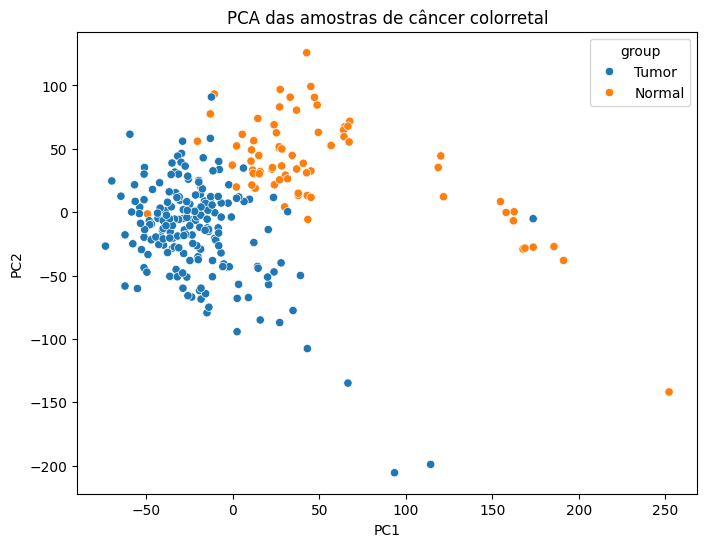

In [13]:
X = expr_df.T

X = X.loc[metadata_filtered["sample_id"]]

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
    "sample_id": X.index
})

pca_df = pca_df.merge(metadata_filtered[["sample_id", "group"]], on="sample_id")

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="group")
plt.title("PCA das amostras de câncer colorretal")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Análise de expressão diferencial

Comparação gene por gene entre tumor e norma.

In [14]:
tumor_samples = metadata_filtered[metadata_filtered["group"] == "Tumor"]["sample_id"].values
normal_samples = metadata_filtered[metadata_filtered["group"] == "Normal"]["sample_id"].values

results = []

for probe in expr_df.index:
    tumor_values = expr_df.loc[probe, tumor_samples]
    normal_values = expr_df.loc[probe, normal_samples]

    # Diferença média
    mean_tumor = tumor_values.mean()
    mean_normal = normal_values.mean()

    # log2 fold-change aproximado
    log2fc = np.log2((mean_tumor+1) / (mean_normal +1))

    # Teste t
    stat, pvalue = stats.ttest_ind(tumor_values, normal_values, equal_var=False)

    results.append({
        "probe_id": probe,
        "mean_tumor": mean_tumor,
        "mean_normal": mean_normal,
        "log2FC": log2fc,
        "pvalue": pvalue
    })

deg_df = pd.DataFrame(results)

# Correção para múltiplos testes
deg_df["adj_pvalue"] = multipletests(deg_df["pvalue"], method="fdr_bh")[1]

deg_df = deg_df.sort_values("adj_pvalue")

deg_df.head(20)

,probe_id,mean_tumor,mean_normal,log2FC,pvalue,adj_pvalue
17776,218412_s_at,225.782258,85.558108,1.389567,7.298356e-72,1.626293e-67
11007,211603_s_at,199.912903,30.492027,2.673512,2.444382e-65,2.723408e-61
1006,201479_at,420.655914,176.214865,1.250567,2.867969e-60,2.130232e-56
1149,201622_at,572.505376,349.378378,0.710893,3.972393e-59,2.212921e-55
2464,202936_s_at,548.467204,156.486486,1.802805,9.538123e-59,4.250760e-55
2755,203228_at,100.518280,41.636486,1.251579,3.598219e-58,1.145416e-54
18347,218984_at,166.236022,73.000000,1.176288,3.150551e-58,1.145416e-54
853,201326_at,244.437634,122.190541,0.994465,4.533420e-58,1.262727e-54
17235,217871_s_at,1068.102151,485.932432,1.134606,1.068774e-57,2.646167e-54
17958,218594_at,146.320968,80.810811,0.848599,5.834391e-57,1.300077e-53


In [15]:
deg_significant = deg_df[
    (deg_df["adj_pvalue"] < 0.05) &
    (abs(deg_df["log2FC"]) > 1)
].copy()

deg_significant.shape

(1388, 6)

Genes mais alterados e mais estatisticamente significativos.

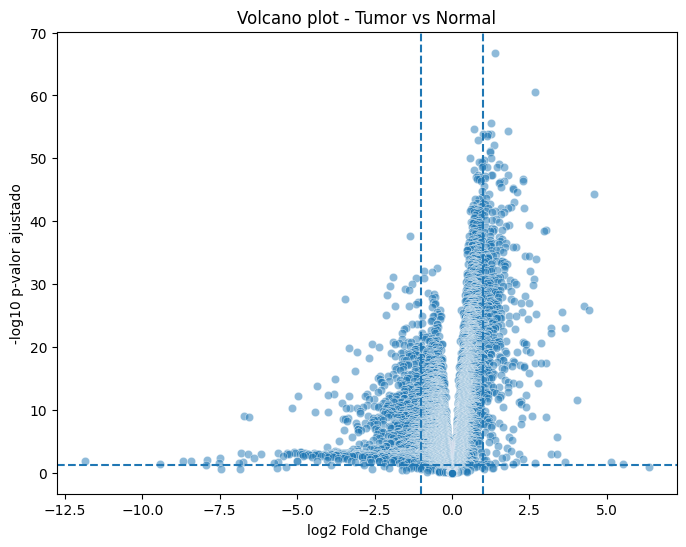

In [16]:
deg_df["-log10_adj_pvalue"] = -np.log10(deg_df["adj_pvalue"])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=deg_df,
    # log2FC=media no Tumor − media no Normal
    x="log2FC",
    y="-log10_adj_pvalue",
    alpha=0.5
)

plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")
plt.axhline(y=-np.log10(0.05), linestyle="--")

plt.title("Volcano plot - Tumor vs Normal")
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 p-valor ajustado")
plt.show()

30 genes mais significativos

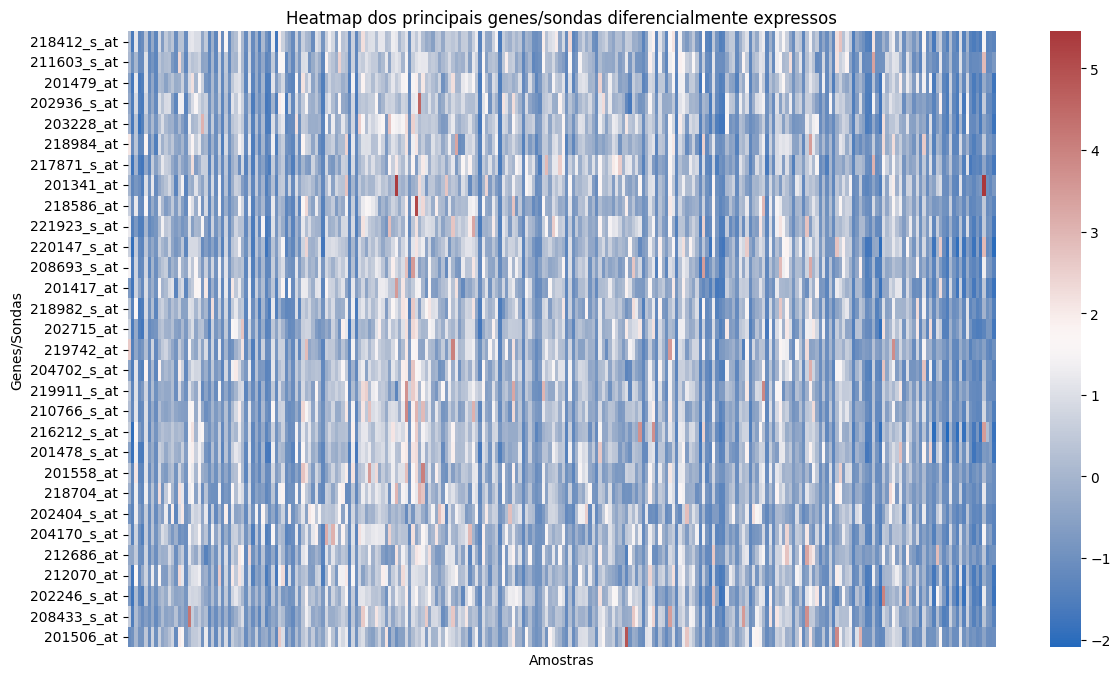

In [17]:
top_markers = deg_significant.head(30)["probe_id"].values

heatmap_data = expr_df.loc[top_markers, metadata_filtered["sample_id"]]

# Padronizar por gene
heatmap_scaled = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0)
heatmap_scaled = heatmap_scaled.div(heatmap_data.std(axis=1), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_scaled, cmap="vlag", xticklabels=False)
plt.title("Heatmap dos principais genes/sondas diferencialmente expressos")
plt.xlabel("Amostras")
plt.ylabel("Genes/Sondas")
plt.show()

# Perfil molecular por paciente/amostra

In [18]:
candidate_markers = deg_significant.head(20)["probe_id"].values

candidate_expr = expr_df.loc[candidate_markers, tumor_samples]

candidate_z = candidate_expr.sub(candidate_expr.mean(axis=1), axis=0)
candidate_z = candidate_z.div(candidate_expr.std(axis=1), axis=0)

candidate_z.head()

,GSM1012286,GSM1012297,GSM1012303,GSM1012305,GSM1012307,GSM1012308,GSM1012310,GSM1012312,GSM1012314,GSM1012316,...,GSM1012627,GSM1012629,GSM1012631,GSM1012634,GSM1012635,GSM1012639,GSM1012643,GSM1012645,GSM1012647,GSM1012651
probe_id,,,,,,,,,,,,,,,,,,,,,
218412_s_at,-0.354472,0.874699,-0.121085,-1.023514,0.532398,-1.505847,0.018947,-0.681214,-0.136644,-0.229999,...,-0.743450,1.621537,-1.085751,-0.556741,0.174538,-0.416708,0.641312,-0.665654,-2.705456,1.310354
211603_s_at,-0.448273,-0.481967,0.674855,-1.591618,-0.021484,-0.549355,-0.358423,-0.223648,-1.462459,2.303392,...,-1.276019,0.809631,-1.423149,-2.022900,0.877019,-0.437042,0.674855,-0.931219,-1.920695,2.988501
201479_at,-1.301696,0.986400,0.775049,-1.145480,-0.401160,-0.594132,-1.356831,-0.658456,-0.171432,-0.869806,...,1.041534,1.206939,1.353965,-0.603321,0.104242,0.306403,-0.373593,0.407484,-2.827093,-1.035211
202936_s_at,-1.092851,0.518763,0.380473,-0.997112,0.726199,-0.151413,0.582589,0.635778,-1.241779,1.188939,...,-1.289649,-1.215185,-1.566229,-1.465171,1.832521,0.125168,0.619821,1.172983,-2.652872,0.061341
203228_at,-0.767765,-0.158872,-0.200153,-0.447838,-0.272395,0.601384,-0.465039,-0.809046,-0.733365,-0.485679,...,-0.420318,-0.974170,0.670186,-1.483301,-0.795286,-0.427198,-0.568241,1.358200,-2.092194,-1.163374


In [19]:
def classify_expression(z):
    if z > 1:
        return "Alta expressão"
    elif z < -1:
        return "Baixa expressão"
    else:
        return "Expressão intermediária"

patient_marker_profile = candidate_z.applymap(classify_expression)

patient_marker_profile.head()

/tmp/ipykernel_2766/2285919713.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  patient_marker_profile = candidate_z.applymap(classify_expression)


,GSM1012286,GSM1012297,GSM1012303,GSM1012305,GSM1012307,GSM1012308,GSM1012310,GSM1012312,GSM1012314,GSM1012316,...,GSM1012627,GSM1012629,GSM1012631,GSM1012634,GSM1012635,GSM1012639,GSM1012643,GSM1012645,GSM1012647,GSM1012651
probe_id,,,,,,,,,,,,,,,,,,,,,
218412_s_at,Expressão intermediária,Expressão intermediária,Expressão intermediária,Baixa expressão,Expressão intermediária,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,...,Expressão intermediária,Alta expressão,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Baixa expressão,Alta expressão
211603_s_at,Expressão intermediária,Expressão intermediária,Expressão intermediária,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Baixa expressão,Alta expressão,...,Baixa expressão,Expressão intermediária,Baixa expressão,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Baixa expressão,Alta expressão
201479_at,Baixa expressão,Expressão intermediária,Expressão intermediária,Baixa expressão,Expressão intermediária,Expressão intermediária,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,...,Alta expressão,Alta expressão,Alta expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Baixa expressão,Baixa expressão
202936_s_at,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Baixa expressão,Alta expressão,...,Baixa expressão,Baixa expressão,Baixa expressão,Baixa expressão,Alta expressão,Expressão intermediária,Expressão intermediária,Alta expressão,Baixa expressão,Expressão intermediária
203228_at,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,...,Expressão intermediária,Expressão intermediária,Expressão intermediária,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Alta expressão,Baixa expressão,Baixa expressão


In [20]:
patient_marker_profile_T = patient_marker_profile.T

patient_marker_profile_T.head()

probe_id,218412_s_at,211603_s_at,201479_at,202936_s_at,203228_at,218984_at,217871_s_at,201341_at,218586_at,221923_s_at,220147_s_at,208693_s_at,201417_at,218982_s_at,202715_at,219742_at,204702_s_at,219911_s_at,210766_s_at,216212_s_at
GSM1012286,Expressão intermediária,Expressão intermediária,Baixa expressão,Baixa expressão,Expressão intermediária,Alta expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Alta expressão,Expressão intermediária,Alta expressão,Baixa expressão,Expressão intermediária,Expressão intermediária,Alta expressão,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária
GSM1012297,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Baixa expressão,Expressão intermediária,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Alta expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Alta expressão
GSM1012303,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Alta expressão,Baixa expressão,Expressão intermediária,Alta expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Alta expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária
GSM1012305,Baixa expressão,Baixa expressão,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Baixa expressão,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Baixa expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária
GSM1012307,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Expressão intermediária,Alta expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária,Alta expressão,Expressão intermediária,Expressão intermediária,Expressão intermediária


/tmp/ipykernel_2766/362567653.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  profile_numeric = patient_marker_profile_T.replace({


<Axes: ylabel='probe_id'>

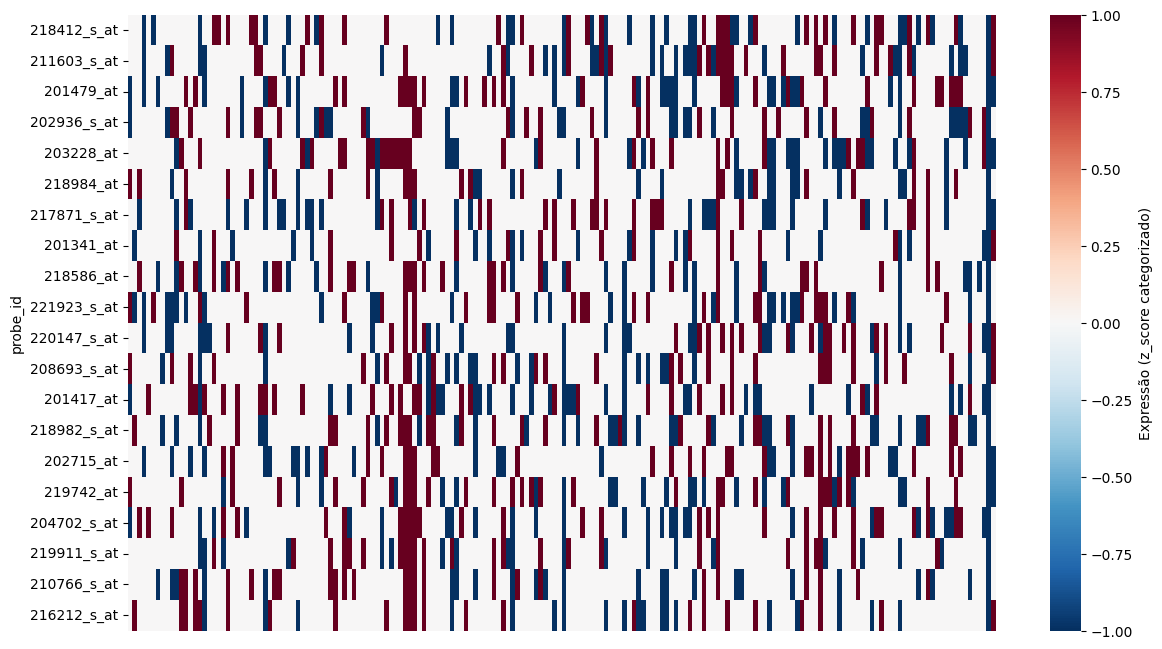

In [21]:
# Como cada marcador candidato se comporta em cada paciente
patient_marker_profile_T.to_csv("perfil_molecular_pacientes.csv")

profile_numeric = patient_marker_profile_T.replace({
    "Alta expressão": 1,
    "Expressão intermediária": 0,
    "Baixa expressão": -1
})

plt.figure(figsize=(14,8))
sns.heatmap(
    profile_numeric.T,
    cmap="RdBu_r",
    center=0,
    xticklabels=False,
    yticklabels=True,
    cbar_kws={"label": "Expressão (z_score categorizado)"}
)

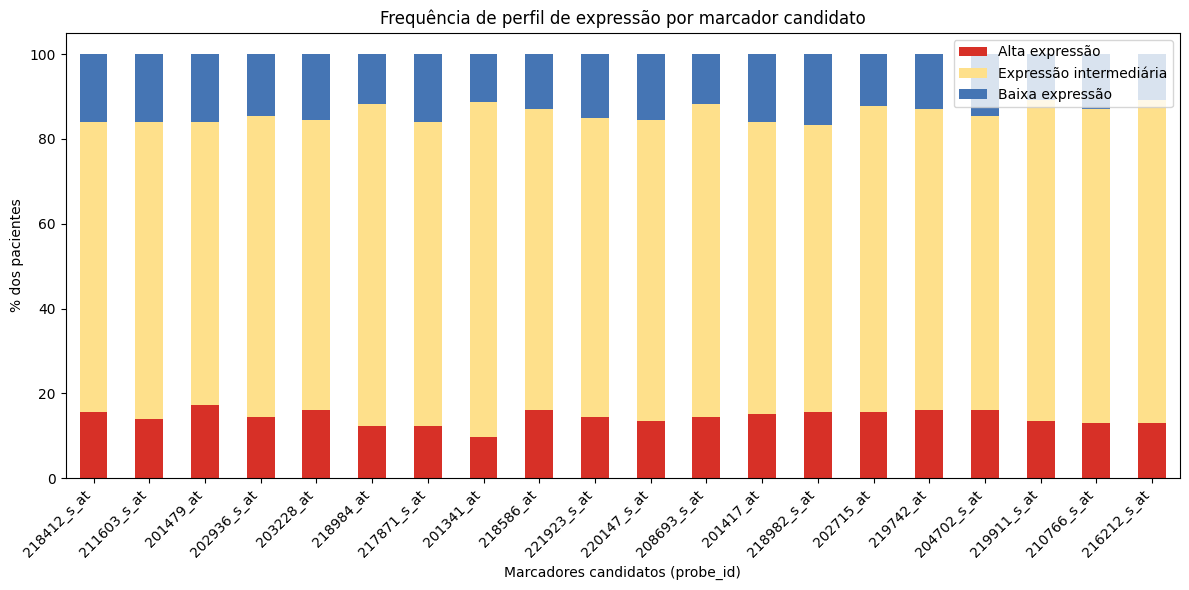

In [22]:
# Consistencia de cada marcador
freq_df = patient_marker_profile_T.apply(
    lambda col: col.value_counts(normalize=True)*100
).T.fillna(0)

freq_df = freq_df[["Alta expressão", "Expressão intermediária", "Baixa expressão"]]

freq_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#d73027", "#fee08b", "#4575b4"]
)

plt.title("Frequência de perfil de expressão por marcador candidato")
plt.xlabel("Marcadores candidatos (probe_id)")
plt.ylabel("% dos pacientes")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [23]:
# Marcadores com maior tendência de alta expressão
pct_high = (patient_marker_profile_T == "Alta expressão").mean() * 100
pct_low  = (patient_marker_profile_T == "Baixa expressão").mean() * 100

consistency_df = pd.DataFrame({
    "pct_alta_expressao": pct_high,
    "pct_baixa_expressao": pct_low
}).sort_values("pct_alta_expressao", ascending=False)

# Marcadores com maior tendência de alta expressão
print("Top marcadores por alta expressão:")
print(consistency_df.head(10))

# Marcadores com maior tendência de baixa expressão (supressores candidatos)
print("\nTop marcadores por baixa expressão:")
print(consistency_df.sort_values("pct_baixa_expressao", ascending=False).head(10))

# Marcadores mais polarizados (alta OU baixa, pouco intermediário)
consistency_df["pct_polarizado"] = consistency_df["pct_alta_expressao"] + consistency_df["pct_baixa_expressao"]
print("\nMarcadores mais polarizados (menos expressão intermediária):")
print(consistency_df.sort_values("pct_polarizado", ascending=False).head(10))

Top marcadores por alta expressão:
             pct_alta_expressao  pct_baixa_expressao
probe_id                                            
201479_at             17.204301            16.129032
204702_s_at           16.129032            14.516129
218586_at             16.129032            12.903226
203228_at             16.129032            15.591398
219742_at             16.129032            12.903226
218982_s_at           15.591398            16.666667
218412_s_at           15.591398            16.129032
202715_at             15.591398            12.365591
201417_at             15.053763            16.129032
202936_s_at           14.516129            14.516129

Top marcadores por baixa expressão:
             pct_alta_expressao  pct_baixa_expressao
probe_id                                            
218982_s_at           15.591398            16.666667
201479_at             17.204301            16.129032
218412_s_at           15.591398            16.129032
201417_at             15.05

# Relacionar com genes conhecidos do câncer colorretal

In [25]:
#42
gse.gpls.keys()

dict_keys(['GPL96'])

In [26]:
#43
platform_id = list(gse.gpls.keys())[0]
platform = gse.gpls[platform_id]
platform.table.head()

,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...


In [27]:
#44
platform.table.columns

Index(['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date',
       'Sequence Type', 'Sequence Source', 'Target Description',
       'Representative Public ID', 'Gene Title', 'Gene Symbol',
       'ENTREZ_GENE_ID', 'RefSeq Transcript ID',
       'Gene Ontology Biological Process', 'Gene Ontology Cellular Component',
       'Gene Ontology Molecular Function'],
      dtype='object')

In [28]:
#45
annotation = platform.table.copy()
annotation.head()

,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...
1,1053_at,M87338,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,M87338 /FEATURE= /DEFINITION=HUMA1SBU Human re...,M87338,"replication factor C (activator 1) 2, 40kDa",RFC2,5982,NM_001278791 /// NM_001278792 /// NM_001278793...,0000278 // mitotic cell cycle // traceable aut...,0005634 // nucleus // inferred from electronic...,0000166 // nucleotide binding // inferred from...
2,117_at,X51757,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,X51757 /FEATURE=cds /DEFINITION=HSP70B Human h...,X51757,heat shock 70kDa protein 6 (HSP70B'),HSPA6,3310,NM_002155,0000902 // cell morphogenesis // inferred from...,0005737 // cytoplasm // inferred from direct a...,0000166 // nucleotide binding // inferred from...
3,121_at,X69699,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,GenBank,X69699 /FEATURE= /DEFINITION=HSPAX8A H.sapiens...,X69699,paired box 8,PAX8,7849,NM_003466 /// NM_013951 /// NM_013952 /// NM_0...,0001655 // urogenital system development // in...,0005634 // nucleus // inferred from direct ass...,0000979 // RNA polymerase II core promoter seq...
4,1255_g_at,L36861,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,L36861 /FEATURE=expanded_cds /DEFINITION=HUMGC...,L36861,guanylate cyclase activator 1A (retina),GUCA1A,2978,NM_000409 /// XM_006715073,0007165 // signal transduction // non-traceabl...,0001750 // photoreceptor outer segment // infe...,0005509 // calcium ion binding // inferred fro...


In [29]:
#46
annotation_simple = annotation[["ID", "Gene Symbol"]].copy()
annotation_simple.columns = ["probe_id", "gene_symbol"]

deg_annotated = deg_df.merge(annotation_simple, on="probe_id", how="left")

deg_annotated.head()

,probe_id,mean_tumor,mean_normal,log2FC,pvalue,adj_pvalue,-log10_adj_pvalue,gene_symbol
0,218412_s_at,225.782258,85.558108,1.389567,7.298356e-72,1.626293e-67,66.788801,GTF2IRD1
1,211603_s_at,199.912903,30.492027,2.673512,2.444382e-65,2.723408e-61,60.564887,ETV4
2,201479_at,420.655914,176.214865,1.250567,2.867969e-60,2.130232e-56,55.671573,DKC1 /// MIR664B /// SNORA56
3,201622_at,572.505376,349.378378,0.710893,3.972393e-59,2.212921e-55,54.655034,SND1
4,202936_s_at,548.467204,156.486486,1.802805,9.538123e-59,4.250760e-55,54.371533,SOX9


In [30]:
# Genes conhecidos
#41
known_crc_genes = [
    "APC", "KRAS", "TP53", "BRAF", "PIK3CA",
    "SMAD4", "MLH1", "MSH2", "MSH6", "EPCAM"
]

crc_known_degs = deg_annotated[
    deg_annotated["gene_symbol"].isin(known_crc_genes)
].copy()

print(f"Genes conhecidos de CRC encontrados nos DEGS: {crc_known_degs.shape[0]}")
print(crc_known_degs[["gene_symbol", "log2FC", "adj_pvalue", "-log10_adj_pvalue"]].sort_values("adj_pvalue"))

Genes conhecidos de CRC encontrados nos DEGS: 19
      gene_symbol    log2FC    adj_pvalue  -log10_adj_pvalue
967          TP53  0.883580  6.578223e-23          22.181891
1592         TP53  0.862343  2.671123e-18          17.573306
1995          APC -0.582609  3.020549e-16          15.519914
1997        SMAD4 -0.525480  3.074022e-16          15.512293
2087          APC -0.420660  8.809014e-16          15.055073
2905         MSH2  0.592707  7.119595e-13          12.147545
3760        SMAD4 -0.316415  1.249319e-10           9.903327
4204         MLH1 -0.210600  1.152551e-09           8.938340
4334         MSH6  0.325981  2.089572e-09           8.679943
4964         MSH6  0.330706  2.807450e-08           7.551688
6585          APC -0.370230  3.442394e-06           5.463139
7895         KRAS -0.224267  5.445508e-05           4.263962
9878        EPCAM  0.349144  9.198920e-04           3.036263
10616        KRAS -0.325393  1.928836e-03           2.714705
14735        KRAS -0.142825  5.89248

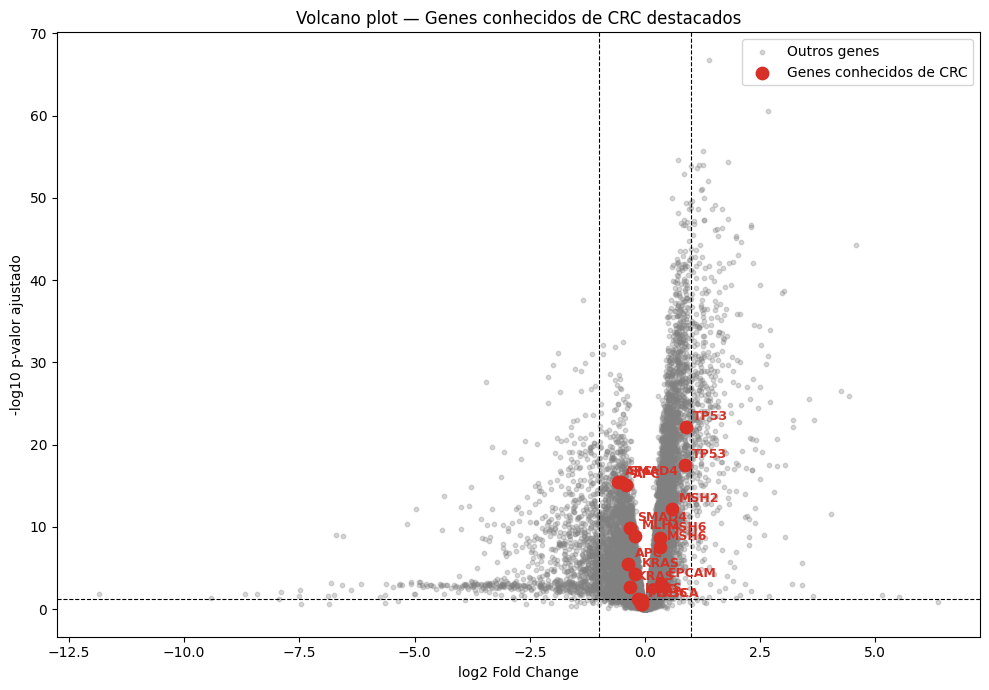

In [32]:
plt.figure(figsize=(10, 7))

plt.scatter(
    deg_annotated["log2FC"],
    deg_annotated["-log10_adj_pvalue"],
    alpha=0.3, color="grey", s=10, label="Outros genes"
)

plt.axvline(x=1, linestyle="--", color="black", linewidth=0.8)
plt.axvline(x=-1, linestyle="--", color="black", linewidth=0.8)
plt.axhline(y=-np.log10(0.05), linestyle="--", color="black", linewidth=0.8)

plt.scatter(
    crc_known_degs["log2FC"],
    crc_known_degs["-log10_adj_pvalue"],
    color="#d73027", s=80, zorder=5, label="Genes conhecidos de CRC"
)

for _, row in crc_known_degs.iterrows():
    plt.annotate(
        row["gene_symbol"],
        xy=(row["log2FC"], row["-log10_adj_pvalue"]),
        xytext=(5, 5), textcoords="offset points",
        fontsize=9, color="#d73027", fontweight="bold"
    )

plt.title("Volcano plot — Genes conhecidos de CRC destacados")
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 p-valor ajustado")
plt.legend()
plt.tight_layout()
plt.show()

# GSEA /Enriquecimento Funcional

In [33]:
!pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.6/664.6 kB 3.5 MB/s eta 0:00:00


In [34]:
print(f"Total de DEGs significativos: {deg_significant.shape[0]}")

deg_significant_annotated = deg_significant.merge(
    annotation_simple, on="probe_id", how="left"
)

print(f"Com símbolo de gene: {deg_significant_annotated['gene_symbol'].notna().sum()}")
print(f"Sem símbolo de gene: {deg_significant_annotated['gene_symbol'].isna().sum()}")

deg_significant_annotated.head(10)

Total de DEGs significativos: 1388
Com símbolo de gene: 1376
Sem símbolo de gene: 12


,probe_id,mean_tumor,mean_normal,log2FC,pvalue,adj_pvalue,gene_symbol
0,218412_s_at,225.782258,85.558108,1.389567,7.298356e-72,1.626293e-67,GTF2IRD1
1,211603_s_at,199.912903,30.492027,2.673512,2.444382e-65,2.723408e-61,ETV4
2,201479_at,420.655914,176.214865,1.250567,2.867969e-60,2.130232e-56,DKC1 /// MIR664B /// SNORA56
3,202936_s_at,548.467204,156.486486,1.802805,9.538123e-59,4.250760e-55,SOX9
4,203228_at,100.518280,41.636486,1.251579,3.598219e-58,1.145416e-54,PAFAH1B3
5,218984_at,166.236022,73.000000,1.176288,3.150551e-58,1.145416e-54,PUS7
6,217871_s_at,1068.102151,485.932432,1.134606,1.068774e-57,2.646167e-54,MIF
7,201341_at,466.026882,179.648649,1.370319,3.859381e-56,7.818054e-53,ENC1
8,218586_at,139.147312,58.289189,1.241103,4.158388e-55,7.721780e-52,MRGBP
9,221923_s_at,662.215054,283.662162,1.220226,6.078180e-55,1.041847e-51,NPM1


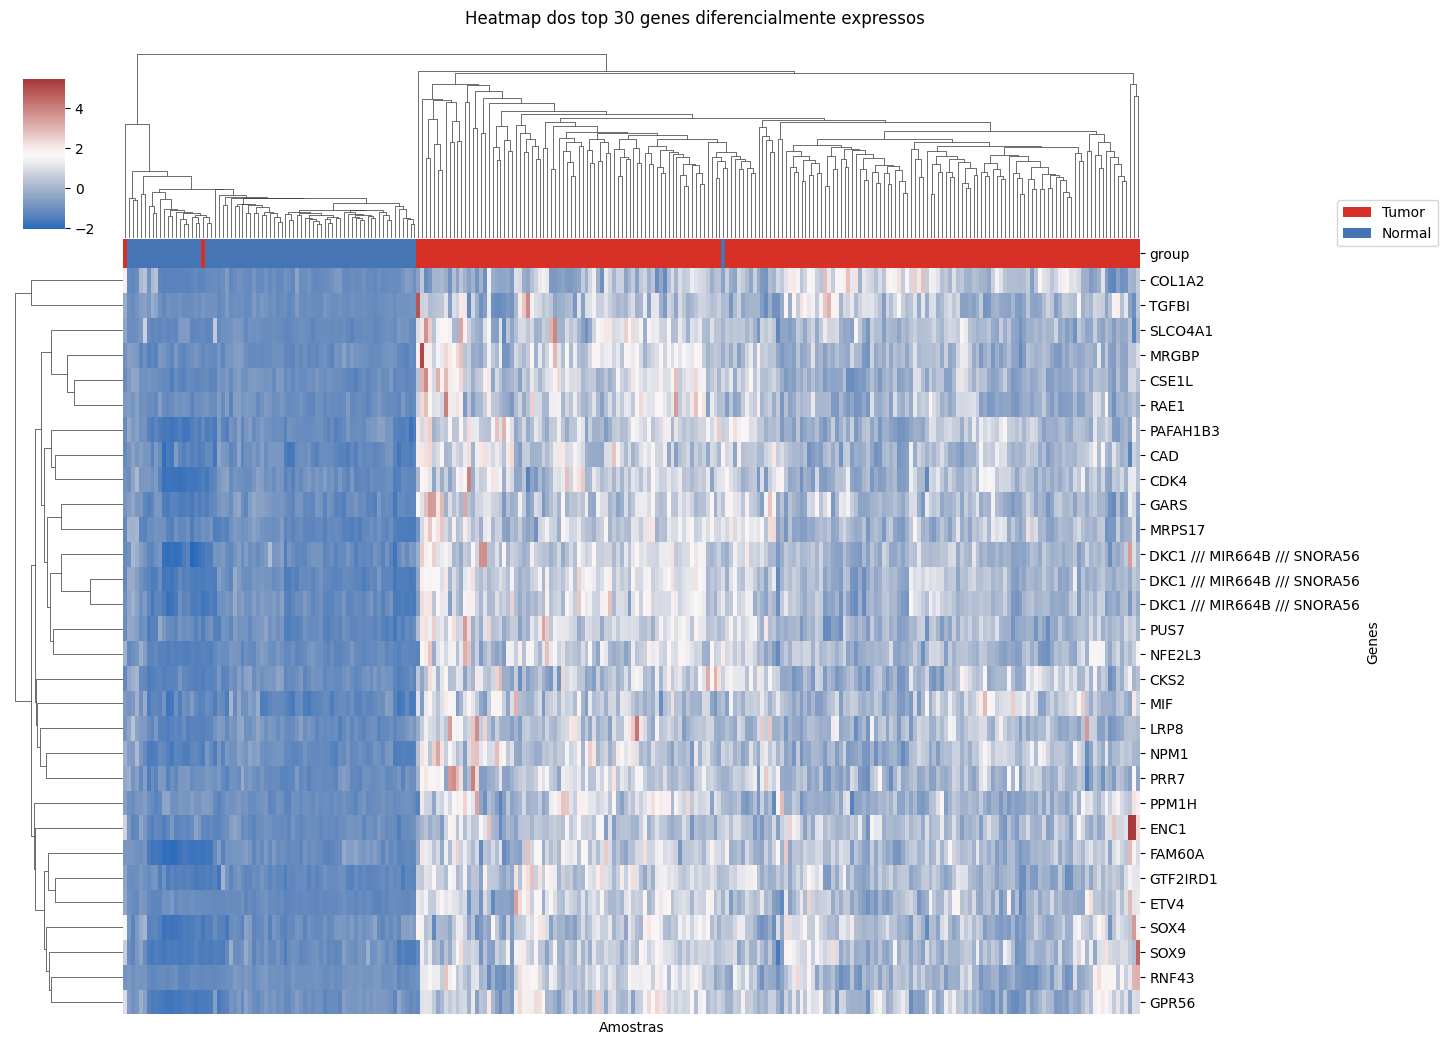

In [35]:
top_markers = deg_significant_annotated.head(30)["probe_id"].values

heatmap_data = expr_df.loc[top_markers, metadata_filtered["sample_id"]]

# Padronizar por gene
heatmap_scaled = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0)
heatmap_scaled = heatmap_scaled.div(heatmap_data.std(axis=1), axis=0)

# Criar barra de cores por grupo
group_colors = metadata_filtered.set_index("sample_id")["group"].map({
    "Tumor": "#d73027",
    "Normal": "#4575b4"
})

probe_to_gene = annotation_simple.set_index("probe_id")["gene_symbol"]
row_labels = [probe_to_gene.get(p, p) for p in top_markers]

g = sns.clustermap(
    heatmap_scaled,
    cmap="vlag",
    col_colors=group_colors,
    xticklabels=False,
    yticklabels=row_labels,
    figsize=(14, 10),
    dendrogram_ratio=(0.1, 0.2),
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)

g.ax_heatmap.set_xlabel("Amostras")
g.ax_heatmap.set_ylabel("Genes")
g.fig.suptitle("Heatmap dos top 30 genes diferencialmente expressos", y=1.02)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d73027", label="Tumor"),
    Patch(facecolor="#4575b4", label="Normal")
]
g.ax_heatmap.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.3, 1.1)
)

plt.show()

In [36]:
top_genes = (
    deg_significant_annotated["gene_symbol"]
    .dropna()
    .loc[~deg_significant_annotated["gene_symbol"].str.contains("///", na=False)]
    .unique()
    .tolist()
)

print(f"Genes únicos para enriquecimento: {len(top_genes)}")
print(top_genes[:10])

Genes únicos para enriquecimento: 1006
['GTF2IRD1', 'ETV4', 'SOX9', 'PAFAH1B3', 'PUS7', 'MIF', 'ENC1', 'MRGBP', 'NPM1', 'FAM60A']




*   **Overlap**: Fração de genes que aparecem na lista. Quanto maior o overlap, mais coberta está via pelos dados
*   **P-value**: Usa o teste estatístico de [Fisher's Exact Test](https://www.geeksforgeeks.org/maths/fisher-exact-test/) para calcular a probabilidade do overlap aparecer por acaso
*   **Adjusted P-value**: A partir da aplicação do [Benjamini-Hochberg](https://www.geeksforgeeks.org/data-science/benjamini-hochberg-procedure/), filtra-se os resultados confiáveis e os não confiáveis (falsos positivos)

In [37]:
import gseapy

enr = gseapy.enrichr(
    gene_list=top_genes,
    gene_sets=["KEGG_2021_Human", "GO_Biological_Process_2021"],
    organism="human",
    outdir=None
)

enr.results.head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Complement and coagulation cascades,49/85,1.684591e-41,5.087465e-39,0,0,26.963369,2531.441531,SERPINA1;PROS1;C4BPA;C4BPB;C8B;C8A;CLU;SERPINA...
1,KEGG_2021_Human,Drug metabolism,32/108,1.178921e-16,1.780171e-14,0,0,8.178104,299.946388,MAOB;ADH1C;MAOA;ADH1B;DPYS;ADH1A;UGT2B28;CYP2C...
2,KEGG_2021_Human,Bile secretion,27/90,2.044792e-14,2.058424e-12,0,0,8.287319,261.223728,AQP8;ABCB4;AQP9;SLC22A1;SLC2A1;UGT2B28;ATP1A2;...
3,KEGG_2021_Human,Retinol metabolism,21/68,8.649713e-12,6.530533e-10,0,0,8.594600,218.934496,ADH1C;ADH1B;ADH1A;UGT2B15;UGT2B17;UGT2B28;HSD1...
4,KEGG_2021_Human,PPAR signaling pathway,21/74,5.231977e-11,3.160114e-09,0,0,7.619213,180.374551,ACSL1;MMP1;APOA2;APOA1;LPL;APOC3;SORBS1;CYP7A1...
5,KEGG_2021_Human,Metabolism of xenobiotics by cytochrome P450,21/76,9.121645e-11,4.591228e-09,0,0,7.341375,169.716339,GSTM2;GSTM1;ADH1C;ADH1B;ADH1A;AKR1C1;UGT2B15;E...
6,KEGG_2021_Human,"Glycine, serine and threonine metabolism",15/40,3.704869e-10,1.598386e-08,0,0,11.484763,249.405442,AOC3;GAMT;ALAS1;SDS;MAOB;GLDC;MAOA;PIPOX;GNMT;...
7,KEGG_2021_Human,Tyrosine metabolism,14/36,8.154617e-10,3.078368e-08,0,0,12.170455,254.694348,AOC3;ADH1C;MAOB;GOT1;HGD;ADH1B;MAOA;ADH1A;TAT;...
8,KEGG_2021_Human,Steroid hormone biosynthesis,17/61,4.874266e-09,1.635587e-07,0,0,7.403024,141.688673,DHRS11;AKR1C1;UGT2B15;AKR1D1;UGT2B17;UGT2B28;H...
9,KEGG_2021_Human,Fatty acid degradation,14/43,1.209900e-08,3.544203e-07,0,0,9.229352,168.252410,ACAA2;ADH1C;ADH1B;ACSL1;ADH1A;ECI2;ACADSB;ACAT...


Vias significativas encontradas: 700


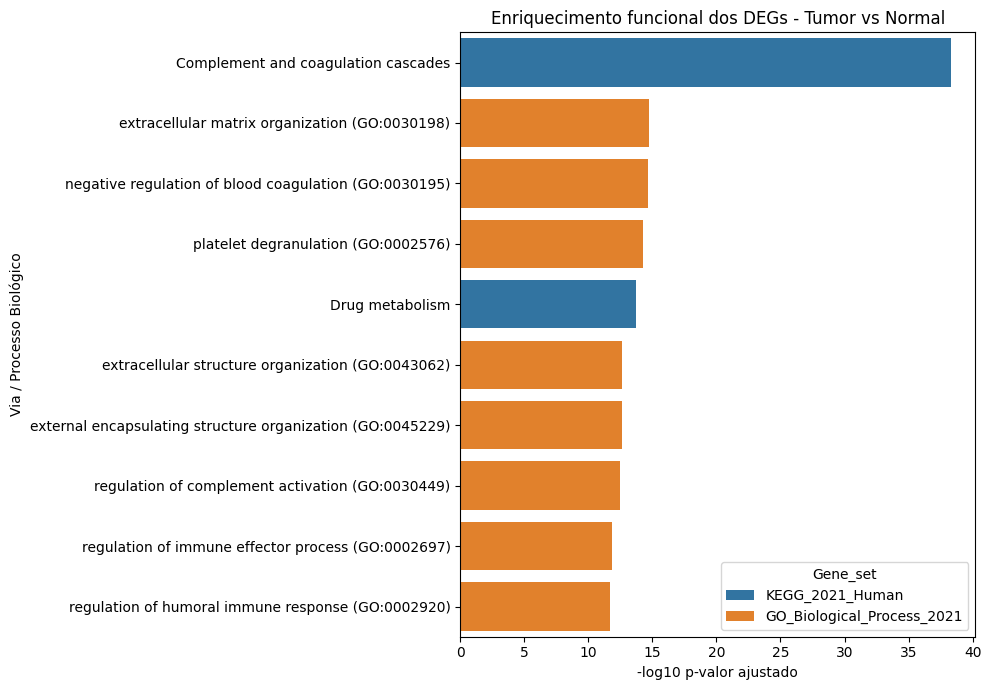

In [38]:
# Filtragem dos resultados
enr_sig = enr.results[enr.results["Adjusted P-value"] < 0.05].copy()

print(f"Vias significativas encontradas: {enr_sig.shape[0]}")

# Top 15
top_pathways = enr_sig.sort_values("Adjusted P-value").head(10)

plt.figure(figsize=(10,7))
sns.barplot(
    data=top_pathways,
    x=-np.log10(top_pathways["Adjusted P-value"]),
    y="Term",
    hue="Gene_set",
    dodge=False
)
plt.xlabel("-log10 p-valor ajustado")
plt.ylabel("Via / Processo Biológico")
plt.title("Enriquecimento funcional dos DEGs - Tumor vs Normal")
plt.tight_layout()
plt.show()

# Consulta ao NCBI Gene - Biopython



In [39]:
from Bio import Entrez
import time

Entrez.email = "victoraugusto2812@gmail.com"

top10_genes = (
    deg_significant_annotated[
        -deg_significant_annotated["gene_symbol"].str.contains("///", na=False)
        & deg_significant_annotated["gene_symbol"].notna()
    ]
    .head(10)["gene_symbol"]
    .tolist()
)

print("Top 10 genes para consulta:")
print(top10_genes)

Top 10 genes para consulta:
['GTF2IRD1', 'ETV4', 'SOX9', 'PAFAH1B3', 'PUS7', 'MIF', 'ENC1', 'MRGBP', 'NPM1', 'FAM60A']


In [40]:
import urllib.request
import xml.etree.ElementTree as ET
import time

gene_summaries = {}

for gene in top10_genes:
    try:
        #ID do gene
        url_search = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi?db=gene&term={gene}[Gene+Name]+AND+Homo+sapiens[Organism]&retmode=xml"
        with urllib.request.urlopen(url_search) as r:
            xml_search = r.read()

        root_search = ET.fromstring(xml_search)
        ids = [el.text for el in root_search.findall(".//Id")]

        if ids:
            gene_id = ids[0]

            url_fetch = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi?db=gene&id={gene_id}&retmode=xml"
            with urllib.request.urlopen(url_fetch) as r:
                xml_fetch = r.read()

            root_fetch = ET.fromstring(xml_fetch)

            doc = root_fetch.find(".//DocumentSummary")

            descricao = doc.findtext("Description") or "N/A"
            resumo = doc.findtext("Summary") or "Resumo não disponível"

            gene_summaries[gene] = {
                "descricao": descricao,
                "resumo": resumo[:400]
            }
        else:
            gene_summaries[gene] = {
                "descricao": "Não encontrado",
                "resumo": "Não encontrado"
            }

        print(f"✓ {gene} consultado")
        time.sleep(2)

    except Exception as e:
        gene_summaries[gene] = {
            "descricao": f"Erro: {str(e)}",
            "resumo": ""
        }
        print(f"✗ {gene} erro: {str(e)}")
        time.sleep(3)

print(f"\nTotal consultados: {len(gene_summaries)}")

✓ GTF2IRD1 consultado
✓ ETV4 consultado
✓ SOX9 consultado
✓ PAFAH1B3 consultado
✓ PUS7 consultado
✓ MIF consultado
✓ ENC1 consultado
✓ MRGBP consultado
✓ NPM1 consultado
✓ FAM60A consultado

Total consultados: 10


In [41]:
for gene in gene_summaries:
    info = gene_summaries[gene]
    print(f"\n{'='*40}")
    print(f"Gene: {gene}")
    print(f"Descrição: {info['descricao']}")
    print(f"Resumo funcional: {info['resumo']}")


Gene: GTF2IRD1
Descrição: GTF2I repeat domain containing 1
Resumo funcional: The protein encoded by this gene contains five GTF2I-like repeats and each repeat possesses a potential helix-loop-helix (HLH) motif. It may have the ability to interact with other HLH-proteins and function as a transcription factor or as a positive transcriptional regulator under the control of Retinoblastoma protein. This gene plays a role in craniofacial and cognitive development and mutations 

Gene: ETV4
Descrição: ETS variant transcription factor 4
Resumo funcional: Enables DNA-binding transcription activator activity, RNA polymerase II-specific and RNA polymerase II cis-regulatory region sequence-specific DNA binding activity. Involved in positive regulation of keratinocyte differentiation and positive regulation of transcription by RNA polymerase II. Located in chromosome and nucleolus. [provided by Alliance of Genome Resources, Jul 2025]

Gene: SOX9
Descrição: SRY-box transcription factor 9
Resumo fu

In [42]:
summary_df = pd.DataFrame({
    "gene_symbol": list(gene_summaries.keys()),
    "descricao": [v["descricao"] for v in gene_summaries.values()],
    "resumo_funcional": [v["resumo"] for v in gene_summaries.values()]
})

summary_df = summary_df.merge(
    deg_significant_annotated[["gene_symbol", "log2FC", "adj_pvalue"]].drop_duplicates("gene_symbol"),
    on="gene_symbol",
    how="left"
)

summary_df = summary_df[["gene_symbol", "log2FC", "adj_pvalue", "descricao", "resumo_funcional"]]

summary_df["adj_pvalue"] = summary_df["adj_pvalue"].apply(lambda x: f"{x:.2e}")
summary_df["log2FC"] = summary_df["log2FC"].round(3)

summary_df

,gene_symbol,log2FC,adj_pvalue,descricao,resumo_funcional
0,GTF2IRD1,1.390,1.63e-67,GTF2I repeat domain containing 1,The protein encoded by this gene contains five...
1,ETV4,2.674,2.72e-61,ETS variant transcription factor 4,Enables DNA-binding transcription activator ac...
2,SOX9,1.803,4.25e-55,SRY-box transcription factor 9,The protein encoded by this gene recognizes th...
3,PAFAH1B3,1.252,1.15e-54,platelet activating factor acetylhydrolase 1b ...,This gene encodes an acetylhydrolase that cata...
4,PUS7,1.176,1.15e-54,pseudouridine synthase 7,Enables enzyme binding activity and tRNA pseud...
5,MIF,1.135,2.65e-54,macrophage migration inhibitory factor,This gene encodes a lymphokine involved in cel...
6,ENC1,1.370,7.82e-53,ectodermal-neural cortex 1,This gene encodes a member of the kelch-relate...
7,MRGBP,1.241,7.72e-52,MRG domain binding protein,Involved in positive regulation of double-stra...
8,NPM1,1.220,1.04e-51,nucleophosmin 1,The protein encoded by this gene is involved i...
9,FAM60A,1.271,1.03e-50,SIN3-HDAC complex associated factor,Involved in negative regulation of cell migrat...


# Discussão

# Conclusão